In [99]:
# from RRAM import Montecarlo as mc


import pandas as pd
import matplotlib.pyplot as plt

In [100]:
# # comienzo leyendo los datos de la simulación almacenados en un archivo csv dentro de la carpeta Init y los guardo en sus respectivas variables
# sim_parmtrs = mc.read_csv_to_dic("Init_data/simulation_parameters.csv")
# sim_ctes = mc.read_csv_to_dic("Init_data/simulation_constants.csv")

# # Defino la carpeta donde se guardan los datos iniciales de la simulación
# carpeta = 'Results'

In [101]:
# def Plot_2panel(data_path: str, title: str = None) -> None:
#     """
#     Función que representa los datos obtenidos de la simulación en un panel con 2 subplots.
#     Los subplots están dispuestos en una columna (uno sobre el otro).

#     Args:
#     data_path: Ruta del archivo CSV con los datos. La primera columna contiene la variable independiente y las siguientes columnas las variables dependientes.
#     title: Título opcional para la figura.

#     Returns:
#         None
#     """

#     # Leo los datos desde el CSV
#     data = pd.read_csv(data_path)

#     # Extraigo la variable independiente y las dos primeras variables dependientes
#     x = data.iloc[:, 0]
#     y = data.iloc[:, 5:7]  # Solo las dos primeras columnas dependientes

#     # Creo la figura y los subplots
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

#     # Establezco el título del conjunto de figuras si se ha proporcionado uno
#     if title is not None:
#         fig.suptitle(title, fontsize=16)

#     # Creo el primer subplot
#     ax1.plot(x, y.iloc[:, 0])
#     ax1.set_title('Velocidad')

#     # añado una etiqueta al eje x
#     ax1.set_xlabel('Tiempo [s]')
#     ax1.set_ylabel('Velocidad [m/s]')

#     # Creo el segundo subplot
#     ax2.plot(x, y.iloc[:, 1])
#     ax2.set_title('Vacantes generadas')

#     # añado una etiqueta al eje x
#     ax2.set_xlabel('Tiempo [s]')
#     ax2.set_ylabel('Vancantes totales')

#     # Ajustamos el espacio entre los plots
#     fig.tight_layout()

#     # Ajusto el espacio para el título principal si se ha proporcionado uno
#     if title is not None:
#         fig.subplots_adjust(top=0.88)

#     # Guardo la figura
#     if title is not None:
#         partes = title.split(',')
#         filename = f"Results/Panel_{data_path.split('/')[-1].split('.')[0]}_{partes[0].split('=')[1].strip()}-{partes[1].split('=')[1].strip()}.png"
#     else:
#         filename = f"Results/Panel_{data_path.split('/')[-1].split('.')[0]}.png"

#     plt.savefig(filename)

#     # Cierro la figura
#     plt.close(fig)

#     return None

In [102]:
# Plot_2panel(f'Results/resultados_0.csv', title=fr'$\gamma^{{drift}} = 9$, $E_mm = 0.9$ eV ')

In [103]:
# # Leo los datos desde el CSV
# data = pd.read_csv('Results/resultados_0.csv')

# # Extraigo la variable independiente y las dos primeras variables dependientes
# x = data.iloc[:, 0]
# y = data.iloc[:, 36]  # Solo las dos primeras columnas dependientes

# # Creo la figura y los subplots
# fig, ax1 = plt.subplots(figsize=(9, 6))

# # Establezco el título del conjunto de figuras si se ha proporcionado uno
# fig.suptitle('Probabilidad de generación', fontsize=16)

# # Creo el primer subplot
# ax1.plot(x, y)

# # añado una etiqueta al eje x
# ax1.set_xlabel('Tiempo [s]')
# ax1.set_ylabel('Probabilidad de generación')

# plt.savefig('Results/Prob_generacion.png')

In [104]:
import pandas as pd
import matplotlib.pyplot as plt


def Plot_2panel(data_path: str, col_indices_x: list, col_indices_y: list, global_tittle: str = None,
                titles: list = None, eje_x: list = None, eje_y: list = None, log_scale: list = [None, None]) -> None:

    # Leer los datos desde el CSV
    data = pd.read_csv(data_path)
    x1, x2 = data.iloc[:, col_indices_x[0]], data.iloc[:, col_indices_x[1]]
    y1, y2 = data.iloc[:, col_indices_y[0]], data.iloc[:, col_indices_y[1]]

    # Crear la figura y los subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 6))

    # Asignar datos y títulos/etiquetas si se proporcionan
    for i, (ax, x, y) in enumerate(zip(axes, [x1, x2], [y1, y2])):
        ax.scatter(x, y, s=5)
        if titles and len(titles) > i:
            ax.set_title(titles[i])
        if eje_x and len(eje_x) > i:
            ax.set_xlabel(eje_x[i])
        if eje_y and len(eje_y) > i:
            ax.set_ylabel(eje_y[i])
        if log_scale and len(log_scale) > i:
            if log_scale[i] == 'x':
                ax.set_xscale('log')
            elif log_scale[i] == 'y':
                ax.set_yscale('log')
            elif log_scale[i] == 'both':
                ax.set_xscale('log')
                ax.set_yscale('log')

    # Título general
    if global_tittle:
        fig.suptitle(global_tittle, fontsize=16)
        fig.subplots_adjust(top=0.88)

    # Ajustar diseño y guardar la figura
    fig.tight_layout()

    # Guardo la figura
    if global_tittle is not None:
        partes = global_tittle.split(',')
        filename = f"Results/Panel_{data_path.split('/')[-1].split('.')[0]}_{partes[0].split('=')[1].strip()}-{partes[1].split('=')[1].strip()}.png"
    else:
        filename = f"Results/Panel_{data_path.split('/')[-1].split('.')[0]}.png"

    plt.savefig(f"{filename}.png")
    plt.show()

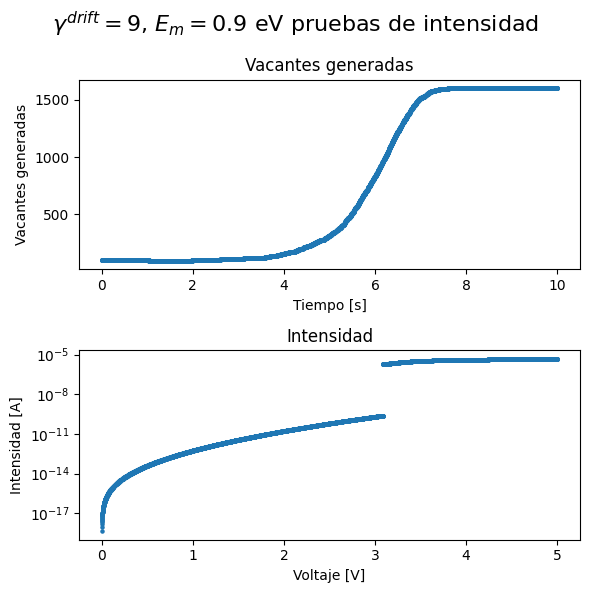

In [105]:
Plot_2panel(data_path=f'Results/resultados_0.csv',
            col_indices_x=[0, 1],
            col_indices_y=[7, 8],
            global_tittle=fr'$\gamma^{{drift}} = 9$, $E_m = 0.9$ eV pruebas de intensidad',
            titles=['Vacantes generadas', 'Intensidad'],
            eje_x=['Tiempo [s]', 'Voltaje [V]'],
            eje_y=['Vacantes generadas', 'Intensidad [A]'],
            log_scale=[None, 'y'])